In [1]:
import numpy as np
import netCDF4 as nc
import numpy.ma as ma

import pandas as pd
import iris
import xarray as xr
import cmocean as co

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

from datetime import datetime
import os

In [2]:
# Functions
def seawater_density(temperature, salinity, pressure):
    """
    Calculate seawater density (kg/m³) using the UNESCO 1981 formula, including pressure effects.

    Valid for:
        - Temperature: -2°C to 40°C
        - Salinity: 0 to 42 PSU
        - Pressure: 0 to 10000 dbar

    Parameters:
        temperature (float): Temperature in °C
        salinity (float): Salinity in PSU
        pressure (float): Pressure in dbar

    Returns:
        float: Seawater density in kg/m³
    """
    # Constants for pure water density (ρ_w)
    a0 = 999.842594
    a1 = 6.793952e-2
    a2 = -9.095290e-3
    a3 = 1.001685e-4
    a4 = -1.120083e-6
    a5 = 6.536332e-9

    # Constants for secant bulk modulus (K)
    b0 = 8.24493e-1
    b1 = -4.08990e-3
    b2 = 7.64380e-5
    b3 = -8.24670e-7
    b4 = 5.38750e-9

    c0 = -5.72466e-3
    c1 = 1.02270e-4
    c2 = -1.65460e-6

    d0 = 4.8314e-4

    e0 = 1.91075e-4
    e1 = -1.60780e-6
    e2 = -1.09810e-8

    f0 = 5.46746e-1
    f1 = -6.03459e-6
    f2 = 1.09987e-8
    f3 = -6.1670e-11

    g0 = 7.944e-2
    g1 = 1.6483e-2
    g2 = -5.3009e-4

    h0 = 3.239908e-3
    h1 = 1.43713e-3
    h2 = 1.16092e-4
    h3 = -5.9395e-7

    i0 = 2.2838e-3
    i1 = -1.0981e-5
    i2 = -1.6078e-6

    j0 = -9.9348e-7
    j1 = 2.0816e-8
    j2 = 9.1697e-10

    # Pure water density (ρ_w) at temperature T
    T = temperature
    T2 = T * T
    T3 = T2 * T
    T4 = T3 * T

    rho_w = (a0 + (a1 + (a2 + (a3 + (a4 + a5 * T) * T) * T) * T) * T)

    # Secant bulk modulus (K) of seawater
    S = salinity
    S15 = S ** 1.5
    K = (b0 + (b1 + (b2 + (b3 + b4 * T) * T) * T) * T +
         (c0 + (c1 + c2 * T) * T) * S + d0 * S15)

    # Density anomaly (σ) at surface pressure
    sigma = (rho_w * S * (b0 + (b1 + b2 * T) * T +
                           (c0 + c1 * T) * S ** 0.5 + d0 * S15)) / K

    # Pressure terms
    P = pressure
    P2 = P * P

    # Pressure contribution to density
    K_P = (e0 + (e1 + e2 * T) * T + (f0 + (f1 + f2 * T) * T + f3 * T2) * S +
           (g0 + g1 * S + g2 * S15) * P + (h0 + (h1 + h2 * T) * T +
           (i0 + (i1 + i2 * T) * T) * S) * P + j0 * P2)

    # Final density (ρ)
    rho = (rho_w + sigma) / (1 - P / K_P)

    return rho

def interpolate_lat_lon(lat, lon):
    df = pd.DataFrame({'lat': lat, 'lon': lon})
    df['lat_interp'] = df['lat'].interpolate(method='linear', limit_direction='both')
    df['lon_interp'] = df['lon'].interpolate(method='linear', limit_direction='both')
    return df['lat_interp'].to_numpy(), df['lon_interp'].to_numpy()

def transformar_valores_menores_al_mas_repetido(chla):
    valores, cuentas = np.unique(chla, return_counts=True)
    indice_max_cuenta = np.argmax(cuentas)
    valor_mas_repetido = valores[indice_max_cuenta]
    chla = np.where(chla < valor_mas_repetido, valor_mas_repetido, chla)
    chla -= valor_mas_repetido
    return chla 

def filtrar_valores_validos_inplace(bbp700, bbp700_qc, lat_interp, lon_interp, days, chla, chla_qc, prof, temp, psal):
    if not np.issubdtype(bbp700_qc.dtype, np.str_):
        bbp700_qc = bbp700_qc.astype(str)
    if not np.issubdtype(chla_qc.dtype, np.str_):
        chla_qc = chla_qc.astype(str)
        
    bbp700 = ma.masked_where(bbp700_qc == '4', bbp700)
    chla = ma.masked_where(chla_qc == '4', chla)
    mascara_filtrado = ~bbp700.mask

    bbp700_filtrado = bbp700[mascara_filtrado]
    lat_filtrada = lat_interp[mascara_filtrado]
    lon_filtrada = lon_interp[mascara_filtrado]
    days_filtrados = days[mascara_filtrado]
    chla_filtrada = transformar_valores_menores_al_mas_repetido(chla[mascara_filtrado])
    prof_filtrada = prof[mascara_filtrado]
    temp_filtrada = temp[mascara_filtrado]
    psal_filtrada = psal[mascara_filtrado]
    
    return bbp700_filtrado, lat_filtrada, lon_filtrada, days_filtrados, chla_filtrada, prof_filtrada, temp_filtrada, psal_filtrada

In [3]:
# Data
argo_numbers = [6901486]
cycles_conv = [117, 118, 119]
cycles = list(range(100, 200))
n = len(cycles)

In [4]:
vmin = 0
vmax = 0.02
# Defining cmap
cmap = plt.get_cmap('twilight')

/scratch/tmp/34145634/ipykernel_61958/2511778930.py:16: RuntimeWarning: divide by zero encountered in log10
,  pl3 = ax2.plot(np.log10(CHL[4,:].data), PROF[4,:].data, label=f"{cycle}", color='lightgray')
,/scratch/tmp/34145634/ipykernel_61958/2511778930.py:16: RuntimeWarning: invalid value encountered in log10
,  pl3 = ax2.plot(np.log10(CHL[4,:].data), PROF[4,:].data, label=f"{cycle}", color='lightgray')
,/scratch/tmp/34145634/ipykernel_61958/2511778930.py:33: RuntimeWarning: invalid value encountered in log10
,  pl4 = ax2.plot(np.log10(CHL[4,:].data), PROF[4,:].data, label=f"{cycle}", color='green')
,/scratch/tmp/34145634/ipykernel_61958/2511778930.py:33: RuntimeWarning: divide by zero encountered in log10
,  pl4 = ax2.plot(np.log10(CHL[4,:].data), PROF[4,:].data, label=f"{cycle}", color='green')


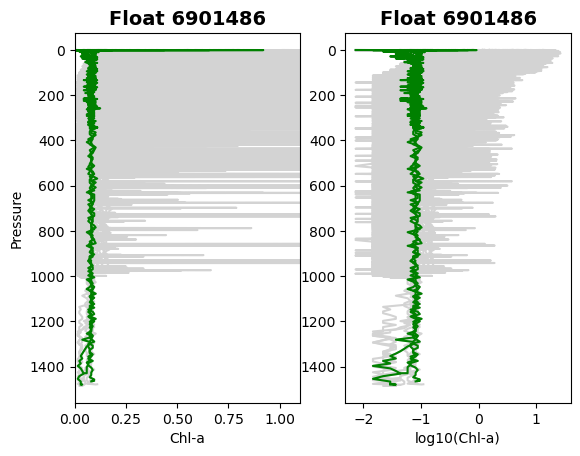

In [5]:
fig, (ax1, ax2) = plt.subplots(1,2)#,figsize=(10, 10))
for argo_number in argo_numbers:
    i=0
    for cycle in cycles:

        file_path = f"/esarchive/obs/argo/bgc/original_files/ftp.ifremer.fr/dac/coriolis/{argo_number}/profiles/BD{argo_number}_{cycle}.nc"
        ds = nc.Dataset(file_path, 'r')
        
        PROF = ds.variables['PRES'][:]
        BBP700 = ds.variables['BBP700'][:]
        CHL = ds.variables['CHLA'][:]
        
        colors = plt.cm.twilight(np.linspace(0,1,n))
        #sc = ax.scatter(BBP700*1.e3, PROF, s=5, label=f"{cycle}", color=colors[i], cmap=cmap); i = i+1
        pl1 = ax1.plot(CHL[4,:].data, PROF[4,:].data, label=f"{cycle}", color='lightgray') 
        pl3 = ax2.plot(np.log10(CHL[4,:].data), PROF[4,:].data, label=f"{cycle}", color='lightgray') 

    for cycle in cycles_conv:

        file_path = f"/esarchive/obs/argo/bgc/original_files/ftp.ifremer.fr/dac/coriolis/{argo_number}/profiles/BD{argo_number}_{cycle}.nc"
        ds = nc.Dataset(file_path, 'r')
        
        PROF = ds.variables['PRES'][:]
        TEMP = ds.variables['TEMP_MED'][:]
        SAL = ds.variables['PSAL_MED'][:]
        RHO = seawater_density(TEMP, SAL, PROF)
        
        BBP700 = ds.variables['BBP700'][:]
        CHL = ds.variables['CHLA'][:]
        
        colors = plt.cm.twilight(np.linspace(0,1,n))
        pl2 = ax1.plot(CHL[4,:].data, PROF[4,:].data, label=f"{cycle}", color='green')      
        pl4 = ax2.plot(np.log10(CHL[4,:].data), PROF[4,:].data, label=f"{cycle}", color='green')         


ax1.set_title(f"Float {argo_number}", fontdict={'weight': 'bold', 'size': 14})
ax1.set_ylabel('Pressure')
ax1.set_xlabel('Chl-a')
ax1.set_xlim([0,1.1])
ax1.invert_yaxis()

ax2.set_title(f"Float {argo_number}", fontdict={'weight': 'bold', 'size': 14})
ax2.set_xlabel('log10(Chl-a)')
ax2.invert_yaxis()

#plt.grid()
#plt.legend()
plt.show()

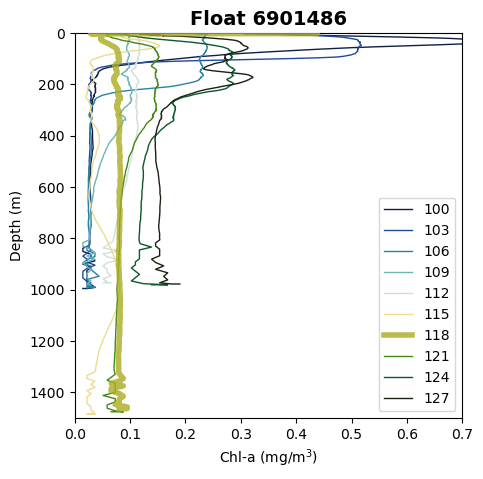

In [6]:
cycles_conv_all = list(range(100, 130))
cycles_conv = cycles_conv_all[::3]
n = len(cycles_conv)

fig, ax = plt.subplots(figsize=(5, 5))
for argo_number in argo_numbers:
    i=0
    for cycle in cycles_conv:

        file_path = f"/esarchive/obs/argo/bgc/original_files/ftp.ifremer.fr/dac/coriolis/{argo_number}/profiles/BD{argo_number}_{cycle}.nc"
        ds = nc.Dataset(file_path, 'r')
        
        PROF = ds.variables['PRES'][:]
        BBP700 = ds.variables['BBP700'][:]
        CHL = ds.variables['CHLA'][:]

        PROFall = PROF[4,:].data[:]
        CHLall  = CHL[4,:].data[:]
        nz = PROFall.shape[0]
        PROFs = PROFall
        CHLs = CHLall

        st = 15
        for zz in range(st,nz-st):
            PROFs[zz] = PROFall[zz-st:zz+st].mean()
            CHLs[zz] = CHLall[zz-st:zz+st].mean()
        
        #colors = plt.cm.viridis(np.linspace(0,1,n))
        colors = co.cm.delta(np.linspace(0,1,n))

        if cycle == 118:
#            pl3 = ax.plot(CHL[4,:].data[::10], PROF[4,:].data[::10], color=colors[i], label=f"{cycle}", linewidth=4, zorder=3, alpha=1)   
            pl3 = ax.plot(CHLs, PROFs, color=colors[i], label=f"{cycle}", linewidth=4, zorder=3, alpha=0.8)   

        else:
            #pl2 = ax.plot(CHL[4,:].data[::10], PROF[4,:].data[::10], color=colors[i], label=f"{cycle}", linewidth=1, zorder=1)    
            pl2 = ax.plot(CHLs, PROFs, color=colors[i], label=f"{cycle}", linewidth=1, zorder=1)    

        i = i+1

ax.set_title(f"Float {argo_number}", fontdict={'weight': 'bold', 'size': 14})
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Chl-a (mg/m$^3$)')
ax.set_xlim([0,0.7])
ax.set_ylim([0,1500])
ax.invert_yaxis()

#plt.grid()
plt.legend()

plt.savefig('Float6901486_CHLcorr_100127_3_CHL.png', format='png',bbox_inches='tight',dpi=300)

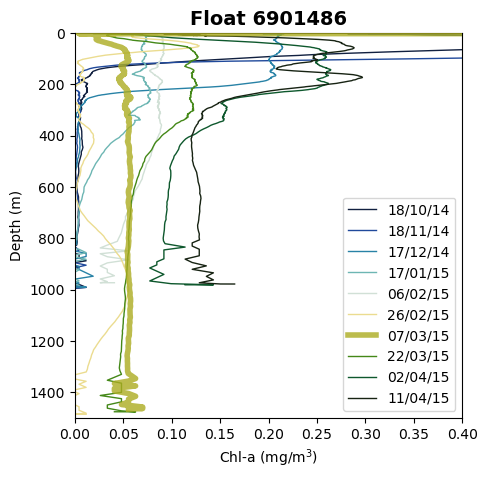

In [8]:
cycles_conv_all = list(range(100, 130))
cycles_conv = cycles_conv_all[::3]
n = len(cycles_conv)
dates = ['18/10/14','18/11/14','17/12/14','17/01/15','06/02/15','26/02/15','07/03/15','22/03/15','02/04/15','11/04/15']

fig, ax = plt.subplots(figsize=(5, 5))
for argo_number in argo_numbers:
    i=0
    for cycle in cycles_conv:

        file_path = f"/esarchive/obs/argo/bgc/original_files/ftp.ifremer.fr/dac/coriolis/{argo_number}/profiles/BD{argo_number}_{cycle}.nc"
        ds = nc.Dataset(file_path, 'r')
        
        PROF = ds.variables['PRES'][:]
        BBP700 = ds.variables['BBP700'][:]
        CHL = ds.variables['CHLA'][:]
        PROFall = PROFs

        PROFall = PROF[4,:].data[:]
        CHLall  = CHL[4,:].data[:] - 0.0248 # Applying correction from timseries baseline (Gali oral communication)
        nz = PROFall.shape[0]
        PROFs = PROFall
        CHLs = CHLall

        st = 15
        for zz in range(st,nz-st):
            PROFs[zz] = PROFall[zz-st:zz+st].mean()
            CHLs[zz] = CHLall[zz-st:zz+st].mean()
        
        #colors = plt.cm.viridis(np.linspace(0,1,n))
        colors = co.cm.delta(np.linspace(0,1,n))

        if cycle == 118:
#            pl3 = ax.plot(CHL[4,:].data[::10], PROF[4,:].data[::10], color=colors[i], label=f"{cycle}", linewidth=4, zorder=3, alpha=1)   
            pl3 = ax.plot(CHLs, PROFs, color=colors[i], label=dates[i], linewidth=4, zorder=3, alpha=0.8)   

        else:
            #pl2 = ax.plot(CHL[4,:].data[::10], PROF[4,:].data[::10], color=colors[i], label=f"{cycle}", linewidth=1, zorder=1)    
            pl2 = ax.plot(CHLs, PROFs, color=colors[i], label=dates[i], linewidth=1, zorder=1)    

        i = i+1

ax.set_title(f"Float {argo_number}", fontdict={'weight': 'bold', 'size': 14})
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Chl-a (mg/m$^3$)')
ax.set_xlim([0,0.4])
ax.set_ylim([0,1500])
ax.invert_yaxis()

#plt.grid()
plt.legend()

plt.savefig('output/Fig_S2.png', format='png',bbox_inches='tight',dpi=300)